In [1]:
import time
import os
import torch
from torch.distributions import Categorical, kl
from d2l.torch import Animator

from net import Net
from aco import ACO
from utils import gen_pyg_data, load_val_dataset

torch.manual_seed(1234)

lr = 3e-4
EPS = 1e-10
T=5
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'


libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
def train_instance(model, optimizer, pyg_data, distances, n_ants, use_mcts=True, mcts_simulations=50):
    model.train()
    heu_vec = model(pyg_data)
    heu_mat = model.reshape(pyg_data, heu_vec) + EPS
    
    aco = ACO(
        n_ants=n_ants,
        heuristic=heu_mat,
        distances=distances,
        device=device,
        use_mcts=use_mcts,
        mcts_simulations=mcts_simulations
        )
    
    costs, log_probs = aco.sample()

    baseline = costs.mean()
    reinforce_loss = torch.sum((costs - baseline) * log_probs.sum(dim=0)) / aco.n_ants
    optimizer.zero_grad()
    reinforce_loss.backward()
    optimizer.step()
    return reinforce_loss.item()

def infer_instance(model, pyg_data, distances, n_ants, use_mcts=True, mcts_simulations=50):
    model.eval()
    heu_vec = model(pyg_data)
    heu_mat = model.reshape(pyg_data, heu_vec) + EPS
    aco = ACO(
        n_ants=n_ants,
        heuristic=heu_mat,
        distances=distances,
        device=device,
        use_mcts=use_mcts,
        mcts_simulations=mcts_simulations
        )
    costs, log_probs = aco.sample()
    aco.run(n_iterations=T)
    baseline = costs.mean()
    best_sample_cost = torch.min(costs)
    best_aco_cost = aco.lowest_cost
    return baseline.item(), best_sample_cost.item(), best_aco_cost.item()

def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50):
    net = Net().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    val_list = load_val_dataset(n_node, k_sparse, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs],
                        legend=["Avg. sample obj.", "Best sample obj.", "Best ACO obj."])

    # 初始验证（epoch = -1）
    avg_bl, avg_best, avg_aco_best = validation(n_ants, -1, net, val_list, animator, use_mcts, mcts_simulations)
    val_results = [(avg_bl, avg_best, avg_aco_best)]

    sum_time = 0
    for epoch in range(0, epochs):
        start = time.time()
        train_epoch(n_node, n_ants, k_sparse, epoch, steps_per_epoch, net, optimizer, use_mcts, mcts_simulations)
        sum_time += time.time() - start
        avg_bl, avg_sample_best, avg_aco_best = validation(n_ants, epoch, net, val_list, animator, use_mcts, mcts_simulations)
        val_results.append((avg_bl, avg_sample_best, avg_aco_best))

    print('total training duration:', sum_time)
    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch+1])

    # 保存模型
    os.makedirs('../pretrained_1/tsp_MCTS', exist_ok=True)
    torch.save(net.state_dict(), f'../pretrained_1/tsp_MCTS/tsp{n_node}.pt')

In [3]:
def train_epoch(n_node,
                n_ants, 
                k_sparse, 
                epoch, 
                steps_per_epoch, 
                net, 
                optimizer,
                use_mcts=True,
                mcts_simulations=50
                ):
    for _ in range(steps_per_epoch):
        instance = torch.rand(size=(n_node, 2), device=device)
        data, distances = gen_pyg_data(instance, k_sparse=k_sparse)
        train_instance(net, optimizer, data, distances, n_ants, use_mcts, mcts_simulations)

In [ ]:
@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, animator=None, use_mcts=True, mcts_simulations=5):
    sum_bl, sum_sample_best, sum_aco_best = 0, 0, 0
    
    for data, distances in val_dataset:
        bl, sample_best, aco_best = infer_instance(net, data, distances, n_ants, use_mcts, mcts_simulations)
        sum_bl += bl; 
        sum_sample_best += sample_best; 
        sum_aco_best += aco_best

    n_val = len(val_dataset)
    avg_bl = sum_bl / n_val
    avg_sample_best = sum_sample_best / n_val
    avg_aco_best = sum_aco_best / n_val

    if animator is not None:
        animator.add(epoch+1, (avg_bl, avg_sample_best, avg_aco_best))
    
    return avg_bl, avg_sample_best, avg_aco_best

Learn heuristic for TSP20: 

NameError: name 'sample_betrain_instancest' is not defined

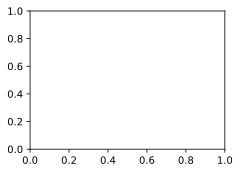

In [5]:
n_node, n_ants = 20, 2
k_sparse = 10
steps_per_epoch = 8
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=1)

Learn heuristic for TSP100: 

total training duration: 59.89045000076294
epoch -1: (21.377930393218993, 19.54834077835083, 18.81059883117676)
epoch 0: (11.399960069656371, 10.481556339263916, 9.709962825775147)
epoch 1: (10.019611587524414, 9.187508735656738, 8.757297139167786)
epoch 2: (9.788645973205567, 9.039171442985534, 8.59729706287384)
epoch 3: (9.729298210144043, 8.997775611877442, 8.618650074005126)
epoch 4: (9.710018243789673, 9.023997449874878, 8.635419101715089)


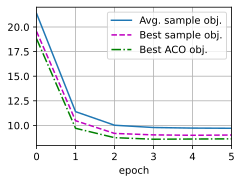

In [ ]:
n_node = 100
n_ants = 20
k_sparse = 20
steps_per_epoch = 128
epochs = 5
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50)

Learn heuristic for TSP500: 

total training duration: 244.93165111541748
epoch -1: (69.20134498596191, 65.89540096282958, 64.83750080108642)
epoch 0: (32.194124908447264, 29.789346141815187, 26.970071601867676)
epoch 1: (22.91804630279541, 21.35917818069458, 20.387555179595946)
epoch 2: (22.124375038146972, 20.94855432510376, 19.854521675109865)
epoch 3: (21.925237503051758, 20.71975757598877, 19.70897176742554)
epoch 4: (21.793745231628417, 20.77731128692627, 19.743974590301512)


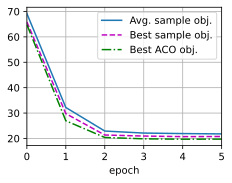

In [ ]:
n_node = 500
n_ants = 50
k_sparse = 50
steps_per_epoch = 128
epochs = 5
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50)